In [8]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# load dataset
df = pd.read_csv("D:\MOHIT\BITSOM\Assignment4(A+B)\ml-assessment-mohit-koli\data\q2_customers.csv")

# view data
df.head()

#scaling
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

#convert back to dataframe
scaled_df = pd.DataFrame(scaled_data, columns=df.columns)
scaled_df.head()


<>:5: SyntaxWarning: invalid escape sequence '\M'
<>:5: SyntaxWarning: invalid escape sequence '\M'
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_17936\4080612155.py:5: SyntaxWarning: invalid escape sequence '\M'
  df = pd.read_csv("D:\MOHIT\BITSOM\Assignment4(A+B)\ml-assessment-mohit-koli\data\q2_customers.csv")


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,-0.725219,-0.176150,0.110166,-0.265011,-0.089951,0.550952
1,-1.488460,-1.046826,0.486157,-0.980466,-0.835176,-0.680685
2,0.176795,0.267337,-0.453822,-0.236851,-0.674046,-0.270139
3,-0.725219,-1.012309,0.298161,-0.827783,-0.996306,-1.091230
4,-1.488460,-1.034488,1.426136,-1.005986,-0.653905,-1.501776


K-Means uses distance to form clusters.
Scaling is required to ensure all features contributes ewually and better clustering performance.
StandaradScaler converts data to mean = 0 and std = 1


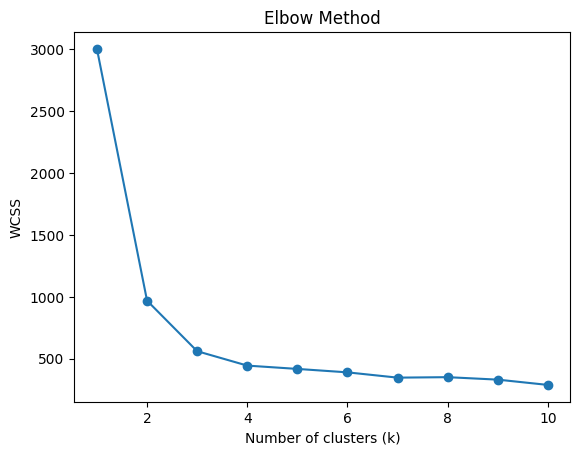

In [10]:
#2. Choosing K using Elbow Method
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_df)
    wcss.append(kmeans.inertia_)

#plot after loop completes
plt.figure()
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()
    

WCSS -  within Cluster Sum of Squares
So as K increases WCSS decreases
So choose K where curve bends(elbow point)
K bends at 3 so choose 3 clusters

In [17]:
#3. K-Means Clustering
from sklearn.cluster import KMeans
K = 3
kmeans = KMeans(n_clusters=K, random_state=42)
kmeans.fit(scaled_df)
df['cluster'] = kmeans.labels_

#view clusters
df.head()

#centroids
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_), columns=df.columns[:-1] 
) # exclude 'cluster' column

centroids

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,24.676471,14847.370588,14.341176,558.970588,9.076471,2.111765
1,56.769697,89413.333333,2.527273,5530.545455,105.357576,7.515152
2,40.387879,43340.733333,8.193939,2021.684848,35.187879,4.424242


1. Cluster0 - High spenders, frequent visit
2. Cluster1 - Low spenders,  low visits
3. Cluster2 - Medium Spenders, regular customers

In [19]:
#4. Dimensionality Reduction using PCA

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_df)

#convert to dataframe
pca_df = pd.DataFrame(pca_data, columns=['PC1', 'PC2'])

#add cluster labels
pca_df['cluster'] = df['cluster']

#Explainded variance
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

#Feature loadings
loadings = pd.DataFrame(pca.components_.T,
 columns=['PC1', 'PC2'], index=scaled_df.columns)

loadings

Explained Variance Ratio: [0.83560354 0.05568764]


,PC1,PC2
age,0.411569,-0.259432
annual_spend,0.421540,-0.033270
visits_per_month,-0.410399,0.208318
basket_size,0.412012,-0.195402
days_since_last_visit,0.378582,0.911194
num_categories_purchased,0.414017,-0.140479


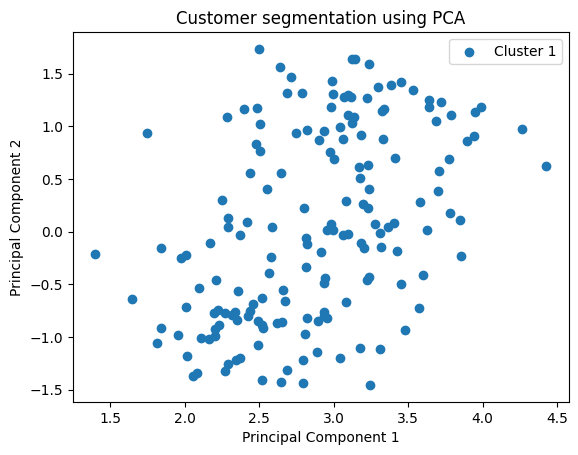

In [20]:
#5. Cluster Visualization

plt.Figure

for cluster in pca_df['cluster'].unique(): subset = pca_df[pca_df['cluster'] == cluster]
plt.scatter(subset['PC1'], subset['PC2'], label=f"Cluster {cluster}")

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2') 
plt.title('Customer segmentation using PCA')   
plt.legend()
plt.show()